# Two measurements on one person

A scatter plot puts one dot per thing you measured twice. Position on the x-axis is one measurement. Position on the y-axis is the other. Nothing is joined, because the people are not a sequence.

Hours on shift, and jobs finished:

| Person | Hours | Jobs |
|---|---:|---:|
| Ada | 30 | 27 |
| Grace | 32 | 34 |
| Alan | 30 | 20 |
| Linus | 31 | 29 |

Ada and Alan worked the same $30$ hours. Ada finished $27$ jobs and Alan finished $20$. The difference is

$$
27 - 20 = 7
$$

Same time, seven fewer jobs. That pair is the point of the chart. Grace worked the most hours and finished the most jobs, but she is not the surprise. Alan is.


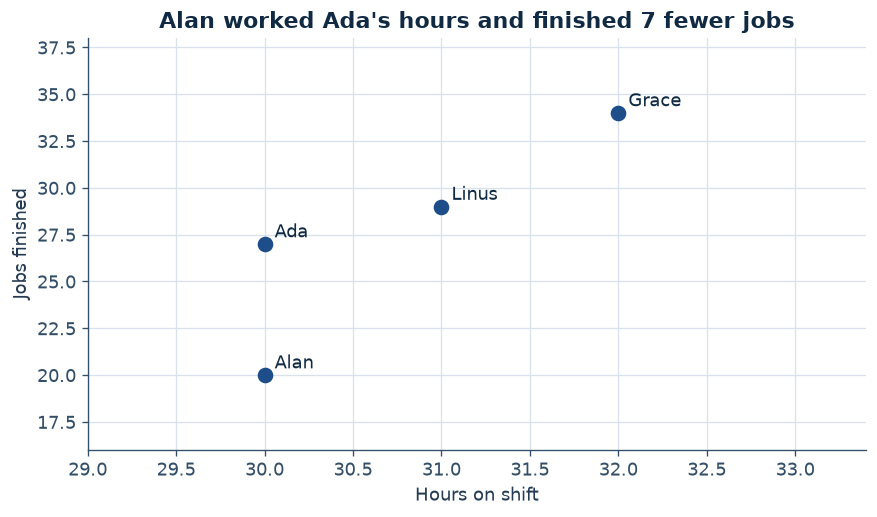

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# One dot per person. Alan shares Ada's hours and not her job count.
names = ["Ada", "Grace", "Alan", "Linus"]
hours = [30, 32, 30, 31]
jobs = [27, 34, 20, 29]
assert jobs[names.index("Ada")] - jobs[names.index("Alan")] == 7
assert hours[names.index("Ada")] == hours[names.index("Alan")] == 30
fig, ax = plt.subplots(constrained_layout=True)
ax.scatter(hours, jobs, s=70, color=BLUE, zorder=3)
for name, x, y in zip(names, hours, jobs):
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 4), color=INK)
ax.set_xlabel("Hours on shift")
ax.set_ylabel("Jobs finished")
ax.set_xlim(29, 33.4)
ax.set_ylim(16, 38)
ax.set_title("Alan worked Ada's hours and finished 7 fewer jobs")


## A jump is not a steady climb

A second pair of measurements, batch size and defects:

$$
(10, 1),\ (20, 2),\ (30, 8),\ (40, 9)
$$

The steps in defects are

$$
2-1 = 1, \qquad 8-2 = 6, \qquad 9-8 = 1
$$

Almost the whole increase happens between batch $20$ and batch $30$. A reader who only says "defects rise with batch size" has missed the only step that matters.


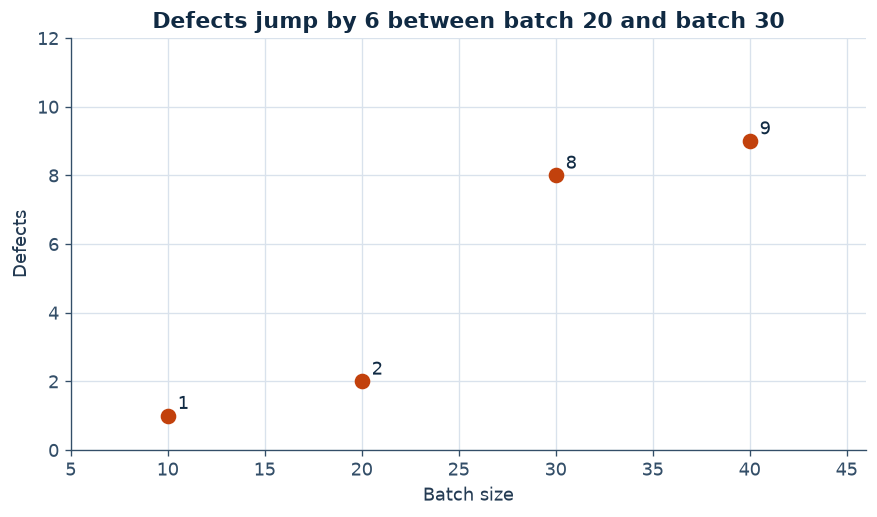

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# The defect step of 6 sits between batch 20 and batch 30.
size = [10, 20, 30, 40]
defects = [1, 2, 8, 9]
steps = [defects[i + 1] - defects[i] for i in range(3)]
assert steps == [1, 6, 1]
fig, ax = plt.subplots(constrained_layout=True)
ax.scatter(size, defects, s=70, color=CLAY, zorder=3)
for x, y in zip(size, defects):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(6, 4), color=INK)
ax.set_xlabel("Batch size")
ax.set_ylabel("Defects")
ax.set_xlim(5, 46)
ax.set_ylim(0, 12)
ax.set_title("Defects jump by 6 between batch 20 and batch 30")


## A pitfall

Connecting the dots in the order of the table draws a path the measurements do not have. Ada is not "before" Grace. A line through the four people would be a route, not a relationship. Leave scatter points unjoined. If the x-axis is time, you wanted a line chart, and the previous lesson already covers it.

This path also does not put a fitted straight line through a scatter. A fit is a claim about a model. The chart here claims only where the points sit.

## What to carry forward

One dot per subject, two measurements, no connecting line. On the shift data, Ada and Alan share $30$ hours and differ by $7$ jobs. On the batch data, the defect step that matters is $6$, between sizes $20$ and $30$.
